<a href="https://colab.research.google.com/github/JohnPaul0403/ai_notebooks/blob/main/forecasting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  !pip install yfinance

In [ ]:
import os
import numpy as np
import pandas as pd
import math
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import KernelPCA
from sklearn.metrics import mean_absolute_error
import tensorflow
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Multiply, Concatenate

In [ ]:
def calculate_rsi(data, period=14):
  """
  Calculate the Relative Strength Index (RSI) for stock data.

  Parameters:
      data (pd.DataFrame): A pandas DataFrame containing at least a 'Close' column.
      period (int): The lookback period for RSI calculation (default is 14).

  Returns:
      pd.Series: A pandas Series containing the RSI values.
  """
  if 'Close' not in data.columns:
      raise ValueError("DataFrame must contain a 'Close' column")

  # Calculate price changes
  delta = data['Close'].diff()

  # Separate gains and losses
  gain = delta.where(delta > 0, 0)
  loss = -delta.where(delta < 0, 0)

  # Calculate average gain and average loss
  avg_gain = gain.rolling(window=period, min_periods=1).mean()
  avg_loss = loss.rolling(window=period, min_periods=1).mean()

  # Compute the Relative Strength (RS)
  rs = avg_gain / avg_loss

  # Calculate the RSI
  rsi = 100 - (100 / (1 + rs))

  return rsi

In [ ]:
def calculate_macd(data, short_period=12, long_period=26, signal_period=9):
  """
  Calculate the Moving Average Convergence Divergence (MACD) for stock data.

  Parameters:
      data (pd.DataFrame): A pandas DataFrame containing at least a 'Close' column.
      short_period (int): The short-term EMA period (default is 12).
      long_period (int): The long-term EMA period (default is 26).
      signal_period (int): The signal line EMA period (default is 9).

  Returns:
      pd.DataFrame: A DataFrame with columns for 'MACD', 'Signal Line', and 'Histogram'.
  """
  if 'Close' not in data.columns:
      raise ValueError("DataFrame must contain a 'Close' column")

  # Calculate short-term EMA and long-term EMA
  short_ema = data['Close'].ewm(span=short_period, adjust=False).mean()
  long_ema = data['Close'].ewm(span=long_period, adjust=False).mean()

  # MACD Line
  macd_line = short_ema - long_ema

  # Signal Line (9-period EMA of MACD Line)
  signal_line = macd_line.ewm(span=signal_period, adjust=False).mean()

  # MACD Histogram
  macd_histogram = macd_line - signal_line

  # Combine results into a DataFrame
  macd_df = pd.DataFrame({
      'MACD': macd_line,
      'Signal Line': signal_line,
      'Histogram': macd_histogram
  })

  return macd_df


In [ ]:
def calculate_sma(data, period=20):
    """
    Calculate the Simple Moving Average (SMA) for stock data.

    Parameters:
        data (pd.DataFrame): A pandas DataFrame containing at least a 'Close' column.
        period (int): The number of periods to calculate the SMA (default is 20).

    Returns:
        pd.Series: A pandas Series containing the SMA values.
    """
    if 'Close' not in data.columns:
        raise ValueError("DataFrame must contain a 'Close' column")

    # Calculate the SMA
    sma = data['Close'].rolling(window=period).mean()

    return sma

In [ ]:
def calculate_cci(data, period=20):
    """
    Calculate Commodity Channel Index (CCI).

    Parameters:
        data (pd.DataFrame): A DataFrame with 'High', 'Low', and 'Close' columns.
        period (int): Lookback period (default is 20).

    Returns:
        pd.Series: A Series containing the CCI values.
    """
    typical_price = (data['High'] + data['Low'] + data['Close']) / 3
    sma = typical_price.rolling(window=period).mean()
    # Calculate mean absolute deviation using numpy
    mean_deviation = typical_price.rolling(window=period).apply(
        lambda x: np.mean(np.abs(x - x.mean())), raw=True  # Calculate MAD using NumPy
    )
    cci = (typical_price - sma) / (0.015 * mean_deviation)
    return cci

In [ ]:
def calculate_aroon(data, period=25):
    """
    Calculate Aroon Up and Aroon Down.

    Parameters:
        data (pd.DataFrame): A DataFrame with a 'Close' column.
        period (int): Lookback period (default is 25).

    Returns:
        pd.DataFrame: A DataFrame with 'Aroon Up' and 'Aroon Down' columns.
    """
    if 'Close' not in data.columns:
        raise ValueError("DataFrame must contain a 'Close' column")

    aroon_up = data['Close'].rolling(window=period).apply(
        lambda x: (period - (period - 1 - x.argmax())) * 100 / period, raw=True
    )
    aroon_down = data['Close'].rolling(window=period).apply(
        lambda x: (period - (period - 1 - x.argmin())) * 100 / period, raw=True
    )

    return pd.DataFrame({'Aroon Up': aroon_up, 'Aroon Down': aroon_down})

In [ ]:
ticker = "SAND-USD"
start_time = "2014-11-01"
end_time = "2024-11-30"
data = yf.download(ticker, start=start_time, end=end_time, interval="5m")

[*********************100%***********************]  1 of 1 completed


In [ ]:
data.head(10)

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SAND-USD,SAND-USD,SAND-USD,SAND-USD,SAND-USD,SAND-USD
Datetime,,,,,,
2024-11-01 00:00:00+00:00,0.243154,0.243154,0.243244,0.243154,0.243244,0
2024-11-01 00:05:00+00:00,0.243439,0.243439,0.243459,0.243439,0.243454,0
2024-11-01 00:10:00+00:00,0.243325,0.243325,0.243374,0.243325,0.243352,14812
2024-11-01 00:15:00+00:00,0.243322,0.243322,0.243322,0.243286,0.243286,0
2024-11-01 00:20:00+00:00,0.243354,0.243354,0.243363,0.243341,0.243341,0
2024-11-01 00:25:00+00:00,0.243292,0.243292,0.243292,0.243181,0.243195,0
2024-11-01 00:30:00+00:00,0.243017,0.243017,0.243330,0.243017,0.243268,11072
2024-11-01 00:35:00+00:00,0.242533,0.242533,0.242992,0.242533,0.242992,0


In [ ]:
#Change column names to Date Adj Close	Close	High	Low	Open	Volume
data.columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']
data.head(10)

,Adj Close,Close,High,Low,Open,Volume
Datetime,,,,,,
2024-11-01 00:00:00+00:00,0.243154,0.243154,0.243244,0.243154,0.243244,0
2024-11-01 00:05:00+00:00,0.243439,0.243439,0.243459,0.243439,0.243454,0
2024-11-01 00:10:00+00:00,0.243325,0.243325,0.243374,0.243325,0.243352,14812
2024-11-01 00:15:00+00:00,0.243322,0.243322,0.243322,0.243286,0.243286,0
2024-11-01 00:20:00+00:00,0.243354,0.243354,0.243363,0.243341,0.243341,0
2024-11-01 00:25:00+00:00,0.243292,0.243292,0.243292,0.243181,0.243195,0
2024-11-01 00:30:00+00:00,0.243017,0.243017,0.243330,0.243017,0.243268,11072
2024-11-01 00:35:00+00:00,0.242533,0.242533,0.242992,0.242533,0.242992,0
2024-11-01 00:40:00+00:00,0.242824,0.242824,0.242825,0.242512,0.242512,9216


In [ ]:
#Add all the indicators
data["RSI"] = calculate_rsi(data)
#concatenate
data = pd.concat([data, calculate_macd(data)], axis=1) # Use pd.concat to concatenate DataFrames
data["SMA"] = calculate_sma(data)
data["CCI"] = calculate_cci(data)
data = pd.concat([data, calculate_aroon(data)], axis=1) # Use pd.concat to concatenate DataFrames

In [ ]:
data.head(10)

,Adj Close,Close,High,Low,Open,Volume,RSI,MACD,Signal Line,Histogram,SMA,CCI,Aroon Up,Aroon Down
Datetime,,,,,,,,,,,,,,
2024-11-01 00:00:00+00:00,0.243154,0.243154,0.243244,0.243154,0.243244,0,NaN,0.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN
2024-11-01 00:05:00+00:00,0.243439,0.243439,0.243459,0.243439,0.243454,0,100.000000,0.000023,4.547716e-06,0.000018,NaN,NaN,NaN,NaN
2024-11-01 00:10:00+00:00,0.243325,0.243325,0.243374,0.243325,0.243352,14812,71.451517,0.000031,9.880045e-06,0.000021,NaN,NaN,NaN,NaN
2024-11-01 00:15:00+00:00,0.243322,0.243322,0.243322,0.243286,0.243286,0,70.919067,0.000037,1.535432e-05,0.000022,NaN,NaN,NaN,NaN
2024-11-01 00:20:00+00:00,0.243354,0.243354,0.243363,0.243341,0.243341,0,73.084446,0.000044,2.111150e-05,0.000023,NaN,NaN,NaN,NaN
2024-11-01 00:25:00+00:00,0.243292,0.243292,0.243292,0.243181,0.243195,0,63.903390,0.000044,2.570066e-05,0.000018,NaN,NaN,NaN,NaN
2024-11-01 00:30:00+00:00,0.243017,0.243017,0.243330,0.243017,0.243268,11072,41.156693,0.000022,2.487918e-05,-0.000003,NaN,NaN,NaN,NaN
2024-11-01 00:35:00+00:00,0.242533,0.242533,0.242992,0.242533,0.242992,0,25.274412,-0.000035,1.292149e-05,-0.000048,NaN,NaN,NaN,NaN
2024-11-01 00:40:00+00:00,0.242824,0.242824,0.242825,0.242512,0.242512,9216,39.349110,-0.000056,-7.695252e-07,-0.000055,NaN,NaN,NaN,NaN


In [ ]:
calculate_sma(data)

,Close
Datetime,
2024-11-01 00:00:00+00:00,NaN
2024-11-01 00:05:00+00:00,NaN
2024-11-01 00:10:00+00:00,NaN
2024-11-01 00:15:00+00:00,NaN
2024-11-01 00:20:00+00:00,NaN
...,...
2024-11-29 23:35:00+00:00,0.652909
2024-11-29 23:40:00+00:00,0.652926
2024-11-29 23:45:00+00:00,0.652923


In [ ]:
data.tail(10)

,Adj Close,Close,High,Low,Open,Volume,RSI,MACD,Signal Line,Histogram,SMA,CCI,Aroon Up,Aroon Down
Datetime,,,,,,,,,,,,,,
2024-11-29 23:10:00+00:00,0.650986,0.650986,0.650986,0.650494,0.650494,318208,38.709703,-0.000028,0.000632,-0.000660,0.653643,-141.145957,72.0,96.0
2024-11-29 23:15:00+00:00,0.649876,0.649876,0.650913,0.649876,0.650913,0,32.037301,-0.000244,0.000457,-0.000700,0.653479,-142.533995,68.0,100.0
2024-11-29 23:20:00+00:00,0.650756,0.650756,0.650845,0.650379,0.650379,330240,35.490260,-0.000339,0.000297,-0.000637,0.653260,-107.605082,64.0,96.0
2024-11-29 23:25:00+00:00,0.651185,0.651185,0.651192,0.651030,0.651030,0,43.210606,-0.000376,0.000163,-0.000539,0.653042,-79.762629,60.0,92.0
2024-11-29 23:30:00+00:00,0.652620,0.652620,0.652765,0.652620,0.652651,0,51.454798,-0.000286,0.000073,-0.000359,0.652907,-13.684240,56.0,88.0
2024-11-29 23:35:00+00:00,0.654575,0.654575,0.654773,0.653298,0.653298,0,58.538335,-0.000057,0.000047,-0.000104,0.652909,55.023593,52.0,84.0
2024-11-29 23:40:00+00:00,0.654749,0.654749,0.655213,0.654749,0.655199,0,54.546294,0.000138,0.000065,0.000073,0.652926,82.820431,48.0,80.0
2024-11-29 23:45:00+00:00,0.655312,0.655312,0.655312,0.654229,0.655050,0,48.353873,0.000334,0.000119,0.000215,0.652923,85.840390,44.0,76.0
2024-11-29 23:50:00+00:00,0.655615,0.655615,0.655615,0.654975,0.654975,2466048,51.910205,0.000507,0.000197,0.000311,0.652933,105.046161,40.0,72.0


In [ ]:
data = data.reset_index()
data.head(10)

,Datetime,Adj Close,Close,High,Low,Open,Volume,RSI,MACD,Signal Line,Histogram,SMA,CCI,Aroon Up,Aroon Down
0,2024-11-01 00:00:00+00:00,0.243154,0.243154,0.243244,0.243154,0.243244,0,NaN,0.000000,0.000000e+00,0.000000,NaN,NaN,NaN,NaN
1,2024-11-01 00:05:00+00:00,0.243439,0.243439,0.243459,0.243439,0.243454,0,100.000000,0.000023,4.547716e-06,0.000018,NaN,NaN,NaN,NaN
2,2024-11-01 00:10:00+00:00,0.243325,0.243325,0.243374,0.243325,0.243352,14812,71.451517,0.000031,9.880045e-06,0.000021,NaN,NaN,NaN,NaN
3,2024-11-01 00:15:00+00:00,0.243322,0.243322,0.243322,0.243286,0.243286,0,70.919067,0.000037,1.535432e-05,0.000022,NaN,NaN,NaN,NaN
4,2024-11-01 00:20:00+00:00,0.243354,0.243354,0.243363,0.243341,0.243341,0,73.084446,0.000044,2.111150e-05,0.000023,NaN,NaN,NaN,NaN
5,2024-11-01 00:25:00+00:00,0.243292,0.243292,0.243292,0.243181,0.243195,0,63.903390,0.000044,2.570066e-05,0.000018,NaN,NaN,NaN,NaN
6,2024-11-01 00:30:00+00:00,0.243017,0.243017,0.243330,0.243017,0.243268,11072,41.156693,0.000022,2.487918e-05,-0.000003,NaN,NaN,NaN,NaN
7,2024-11-01 00:35:00+00:00,0.242533,0.242533,0.242992,0.242533,0.242992,0,25.274412,-0.000035,1.292149e-05,-0.000048,NaN,NaN,NaN,NaN
8,2024-11-01 00:40:00+00:00,0.242824,0.242824,0.242825,0.242512,0.242512,9216,39.349110,-0.000056,-7.695252e-07,-0.000055,NaN,NaN,NaN,NaN
9,2024-11-01 00:45:00+00:00,0.243090,0.243090,0.243090,0.242807,0.242807,0,48.250415,-0.000050,-1.058172e-05,-0.000039,NaN,NaN,NaN,NaN


In [ ]:
imputer = SimpleImputer(missing_values=np.nan)  # Handling missing values
data.drop(columns=['Datetime'], inplace=True)
data = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)
data = data.reset_index(drop=True)

In [ ]:
# Applying feature scaling
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(data.to_numpy())
df_scaled = pd.DataFrame(df_scaled, columns=list(data.columns))
target_scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled[['Open', 'Close']] = target_scaler.fit_transform(data[['Open', 'Close']].to_numpy())
df_scaled = df_scaled.astype(float)

In [ ]:
df_scaled.head(10)

,Adj Close,Close,High,Low,Open,Volume,RSI,MACD,Signal Line,Histogram,SMA,CCI,Aroon Up,Aroon Down
0,0.031314,0.031314,0.030935,0.031564,0.031535,0.000000,0.527116,0.324504,0.326748,0.506630,0.236892,0.506429,0.537474,0.440352
1,0.031771,0.031771,0.031279,0.032026,0.031873,0.000000,1.000000,0.324889,0.326831,0.507461,0.236892,0.506429,0.537474,0.440352
2,0.031588,0.031588,0.031143,0.031841,0.031708,0.000083,0.714515,0.325032,0.326927,0.507604,0.236892,0.506429,0.537474,0.440352
3,0.031584,0.031584,0.031060,0.031778,0.031602,0.000000,0.709191,0.325134,0.327027,0.507630,0.236892,0.506429,0.537474,0.440352
4,0.031636,0.031636,0.031125,0.031868,0.031691,0.000000,0.730844,0.325251,0.327131,0.507682,0.236892,0.506429,0.537474,0.440352
5,0.031535,0.031535,0.031012,0.031608,0.031457,0.000000,0.639034,0.325250,0.327214,0.507469,0.236892,0.506429,0.537474,0.440352
6,0.031094,0.031094,0.031073,0.031343,0.031574,0.000062,0.411567,0.324870,0.327199,0.506480,0.236892,0.506429,0.537474,0.440352
7,0.030316,0.030316,0.030532,0.030558,0.031129,0.000000,0.252744,0.323913,0.326983,0.504444,0.236892,0.506429,0.537474,0.440352
8,0.030784,0.030784,0.030265,0.030525,0.030356,0.000052,0.393491,0.323565,0.326734,0.504127,0.236892,0.506429,0.537474,0.440352
9,0.031212,0.031212,0.030689,0.031003,0.030831,0.000000,0.482504,0.323661,0.326557,0.504836,0.236892,0.506429,0.537474,0.440352


In [ ]:
# Single step dataset preparation
def singleStepSampler(df, window):
    xRes = []
    yRes = []
    for i in range(0, len(df) - window):
        res = []
        for j in range(0, window):
            r = []
            for col in df.columns:
                r.append(df[col][i + j])
            res.append(r)
        xRes.append(res)
        yRes.append(df[['Open', 'Close']].iloc[i + window].values)
    return np.array(xRes), np.array(yRes)

In [ ]:
# Dataset splitting
SPLIT = 0.85
(xVal, yVal) = singleStepSampler(df_scaled, 20)
X_train = xVal[:int(SPLIT * len(xVal))]
y_train = yVal[:int(SPLIT * len(yVal))]
X_test = xVal[int(SPLIT * len(xVal)):]
y_test = yVal[int(SPLIT * len(yVal)):]

In [ ]:
def reduce_sum_layer(x):
    """Custom function for Lambda layer."""
    return tf.reduce_sum(x, axis=1)  # tf is now imported here

In [ ]:
import tensorflow as tf
class AttentionLSTMModel:
  def __init__(self, input_shape, lstm_units=64, dense_units=64, dropout_rate=0.2):
    """
    Initializes the Attention-Based LSTM model.
    :param input_shape: Shape of the input data (time_steps, features).
    :param lstm_units: Number of units in the LSTM layer.
    :param dense_units: Number of units in the dense layer.
    :param dropout_rate: Dropout rate for regularization.
    """
    self.input_shape = input_shape
    self.lstm_units = lstm_units
    self.dense_units = dense_units
    self.dropout_rate = dropout_rate
    self.model = self._build_model()

  def _attention_mechanism(self, inputs):
    """
    Creates an attention mechanism to focus on relevant time steps.
    :param inputs: LSTM output sequence (time_steps, lstm_units).
    :return: Context vector with weighted importance of each time step.
    """
    attention_weights = Dense(1, activation="tanh")(inputs)  # Compute attention scores
    attention_weights = tf.keras.layers.Softmax(axis=1)(attention_weights)  # Normalize scores
    context_vector = Multiply()([inputs, attention_weights])  # Apply weights to LSTM outputs
    context_vector = tf.keras.layers.Lambda(reduce_sum_layer, output_shape=(self.lstm_units,))(context_vector)
    return context_vector

  def _build_model(self):
    """
    Builds the Attention-Based LSTM model.
    :return: Compiled Keras model.
    """
    # Input layer
    inputs = Input(shape=self.input_shape)

    # LSTM layer
    lstm_out, state_h, state_c = LSTM(self.lstm_units, return_sequences=True, return_state=True)(inputs)

    # Attention mechanism
    context_vector = self._attention_mechanism(lstm_out)

    # Combine attention output and LSTM's final hidden state
    combined = Concatenate()([context_vector, state_h])

    # Dense layers
    dense_1 = Dense(self.dense_units, activation="relu")(combined)
    dropout_1 = Dropout(self.dropout_rate)(dense_1)
    output = Dense(2)(dropout_1)  # Output layer for regression (e.g., stock price)

    # Define the model
    model = Model(inputs=inputs, outputs=output)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

  def summary(self):
    """Prints the model summary."""
    self.model.summary()

  def get_model(self):
    """Returns the compiled Keras model."""
    return self.model

In [ ]:
class AttentionLSTMTrainer:
  def __init__(self, model, input_shape, save_dir="model_checkpoints"):
    """
    Initializes the trainer class.
    :param model: The compiled Attention-Based LSTM model.
    :param input_shape: Shape of the input data (time_steps, features).
    :param save_dir: Directory to save model checkpoints.
    """
    self.model = model
    self.input_shape = input_shape
    self.save_dir = save_dir
    os.makedirs(save_dir, exist_ok=True)

  def train(self, X_train, y_train, X_val, y_val, batch_size=32, epochs=50, save_best_only=True):
    """
    Trains the model and saves the best checkpoint.
    :param X_train: Training features, shape (samples, time_steps, features).
    :param y_train: Training targets, shape (samples,).
    :param X_val: Validation features, shape (samples, time_steps, features).
    :param y_val: Validation targets, shape (samples,).
    :param batch_size: Batch size for training.
    :param epochs: Number of epochs to train.
    :param save_best_only: If True, saves only the best model based on validation loss.
    """
    checkpoint_path = os.path.join(self.save_dir, "best_model.keras")
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(
            filepath=checkpoint_path,
            monitor="val_loss",
            save_best_only=save_best_only,
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True,
            verbose=1,
        ),
    ]

    history = self.model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    return history

  def evaluate(self, X_test, y_test):
    """
    Evaluates the model on test data.
    :param X_test: Test features, shape (samples, time_steps, features).
    :param y_test: Test targets, shape (samples,).
    :return: Dictionary containing loss and metrics.
    """
    test_loss, test_mae = self.model.evaluate(X_test, y_test, verbose=1)
    print(f"Test Loss: {test_loss:.4f}, Test MAE: {test_mae:.4f}")
    return {"loss": test_loss, "mae": test_mae}

  def predict(self, X):
    """
    Predicts the target values for the given input.
    :param X: Input features, shape (samples, time_steps, features).
    :return: Predicted target values.
    """
    predictions = self.model.predict(X, verbose=0)
    return predictions

  def save_model(self, file_path="attention_lstm_model.h5"):
    """
    Saves the trained model to a file.
    :param file_path: Path to save the model.
    """
    self.model.save(file_path)
    print(f"Model saved to {file_path}")

  def load_model(self, file_path="attention_lstm_model.h5"):
    """
    Loads a model from a file.
    :param file_path: Path to the saved model.
    """
    custom_objects = {'mse': tf.keras.losses.MeanSquaredError(), 'reduce_sum_layer': reduce_sum_layer}
    self.model = tf.keras.models.load_model(file_path, compile=True, custom_objects=custom_objects)
    print(f"Model loaded from {file_path}")

  def calculate_metrics(self, y_true, y_pred):
    """
    Calculates custom metrics (e.g., MAE) for predictions.
    :param y_true: Ground truth values.
    :param y_pred: Predicted values.
    :return: Dictionary of calculated metrics.
    """
    mae = mean_absolute_error(y_true, y_pred)
    return {"mae": mae}

In [ ]:
multivariate_lstm = AttentionLSTMModel(input_shape=(20, 14))
multivariate_lstm.model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 20, 14)         │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lstm (LSTM)               │ [(None, 20, 64),       │         20,224 │ input_layer[0][0]      │
│                           │ (None, 64), (None,     │                │                        │
│                           │ 64)]                   │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 20, 1)          │             65 │ lstm[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ softmax (Softmax)         │ (None, 20, 1)          │              0 │ dense[0][0]            │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 20, 64)         │              0 │ lstm[0][0],            │
│                           │                        │                │ softmax[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 64)             │              0 │ multiply[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 128)            │              0 │ lambda[0][0],          │
│                           │                        │                │ lstm[0][1]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_1 (Dense)           │ (None, 64)             │          8,256 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 64)             │              0 │ dense_1[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_2 (Dense)           │ (None, 2)              │            130 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 28,675 (112.01 KB)

 Trainable params: 28,675 (112.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
trainer = AttentionLSTMTrainer(multivariate_lstm.model, input_shape=(20, 14))
history = trainer.train(X_train, y_train, X_test, y_test, batch_size=32, epochs=50, save_best_only=True)

Epoch 1/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0051 - mae: 0.0415
Epoch 1: val_loss improved from inf to 0.00041, saving model to model_checkpoints/best_model.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 0.0051 - mae: 0.0414 - val_loss: 4.0900e-04 - val_mae: 0.0157
Epoch 2/50
222/222 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0012 - mae: 0.0198
Epoch 2: val_loss improved from 0.00041 to 0.00037, saving model to model_checkpoints/best_model.keras
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0012 - mae: 0.0198 - val_loss: 3.6860e-04 - val_mae: 0.0166
Epoch 3/50
218/222 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.9759e-04 - mae: 0.0174
Epoch 3: val_loss did not improve from 0.00037
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9635e-04 - mae: 0.0174 - val_loss: 6.6224e-04 - val_mae: 0.0225
Epoch 4/50
213/222 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.9149e-04 - mae: 0.0157
Epoch 4: val_loss did not improve from 0.00037
222/222 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms

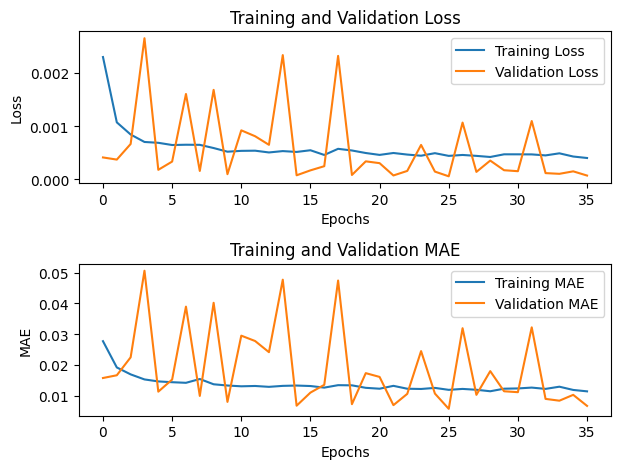

In [ ]:
#MAE plot and val_loss
plt.subplot(211)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(212)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Training and Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Reload the data with the date index
dataFrame = yf.download(ticker, start=start_time, end=end_time, interval="5m")
dataFrame.columns = ['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume']

[*********************100%***********************]  1 of 1 completed


In [ ]:
# Forecast Plot with Dates on X-axis
trainer.evaluate(X_test, y_test)
predicted_values = trainer.predict(X_test)

d = {
    'Predicted_Open': predicted_values[:, 0],
    'Predicted_Close': predicted_values[:, 1],
    'Actual_Open': y_test[:, 0],
    'Actual_Close': y_test[:, 1],
}

d = pd.DataFrame(d)
d.index = dataFrame.index[-len(y_test):]

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.1576e-05 - mae: 0.0065
Test Loss: 0.0001, Test MAE: 0.0057


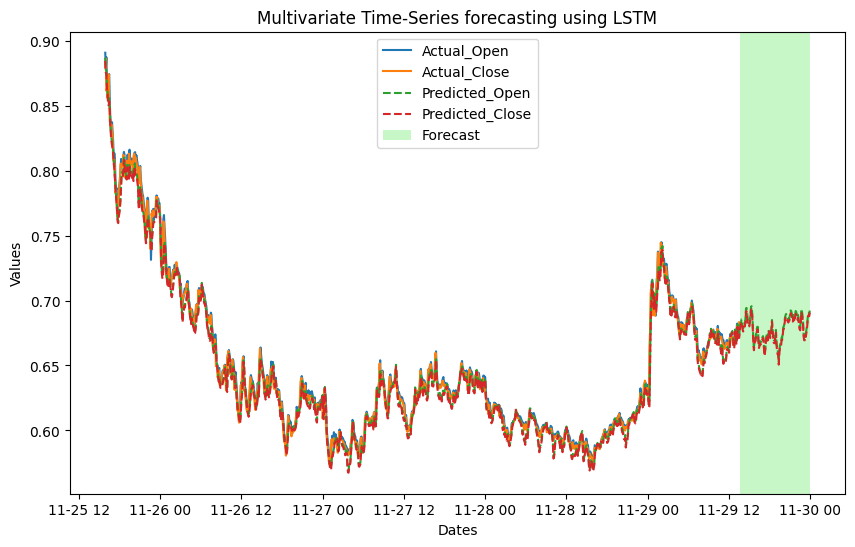

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
#  highlight the  forecast
highlight_start = int(len(d) * 0.9)
highlight_end = len(d) - 1  # Adjusted to stay within bounds
# Plot the actual values
plt.plot(d[['Actual_Open', 'Actual_Close']][:highlight_start], label=['Actual_Open', 'Actual_Close'])

# Plot predicted values with a dashed line
plt.plot(d[['Predicted_Open', 'Predicted_Close']], label=['Predicted_Open', 'Predicted_Close'], linestyle='--')

# Highlight the forecasted portion with a different color
plt.axvspan(d.index[highlight_start], d.index[highlight_end], facecolor='lightgreen', alpha=0.5, label='Forecast')

plt.title('Multivariate Time-Series forecasting using LSTM')
plt.xlabel('Dates')
plt.ylabel('Values')
ax.legend()
plt.show()

In [ ]:
trainer.save_model()

Model saved to attention_lstm_model.h5


In [ ]:
trainer.load_model()

Model loaded from attention_lstm_model.h5


In [ ]:
import tensorflow as tf

In [ ]:
model = trainer.model
# Recompile the loaded model
model.compile(loss='mse', optimizer='adam', metrics=['mae']) # Replace with the original loss, optimizer, and metrics
model.evaluate(X_test, y_test)

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 20, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 17.4539 - mae: 4.1064


[15.438504219055176, 3.87693190574646]

In [ ]:
model.predict(X_test)

32/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 20, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


array([[5.186909 , 6.5535216],
       [5.1899395, 6.571225 ],
       [5.2036443, 6.601555 ],
       ...,
       [4.336228 , 5.261385 ],
       [4.3350368, 5.2636676],
       [4.33681  , 5.270779 ]], dtype=float32)

In [ ]:
X_test[0]

array([[8.04908711e-01, 8.04908711e-01, 8.09089813e-01, 8.11153424e-01,
        8.14895492e-01, 0.00000000e+00, 2.66175674e-01, 1.70288333e-01,
        1.93837020e-01, 4.25194152e-01, 8.83841836e-01, 3.79528704e-01,
        4.16666667e-02, 8.75000000e-01],
       [7.97129353e-01, 7.97129353e-01, 7.98959019e-01, 8.02745781e-01,
        8.04696916e-01, 0.00000000e+00, 1.72248983e-01, 1.62451089e-01,
        1.85696767e-01, 4.24548728e-01, 8.79583666e-01, 3.60406610e-01,
        0.00000000e+00, 1.00000000e+00],
       [7.98609553e-01, 7.98609553e-01, 7.96005865e-01, 8.02635835e-01,
        8.01724004e-01, 0.00000000e+00, 1.78846335e-01, 1.59401094e-01,
        1.78531054e-01, 4.34375350e-01, 8.75597801e-01, 3.68640509e-01,
        0.00000000e+00, 9.58333333e-01],
       [8.06785656e-01, 8.06785656e-01, 8.03115599e-01, 8.04842865e-01,
        8.00528560e-01, 9.63883072e-04, 2.56943402e-01, 1.65761877e-01,
        1.74161384e-01, 4.62568844e-01, 8.72183758e-01, 3.99687121e-01,
        0.000

In [ ]:
new_data = np.random.rand(5, 30, 10)  # 5 samples, 30 time steps, 10 features

# Predict the output
predictions = model.predict(new_data, verbose=0)

/usr/local/lib/python3.10/dist-packages/keras/src/ops/nn.py:545: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, None, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


In [ ]:
predictions

array([[2.148044 , 3.0639322],
       [2.3607533, 3.0933444],
       [2.0921693, 3.4242399],
       [1.7949417, 3.5851548],
       [2.0594542, 3.62512  ]], dtype=float32)

In [ ]:
#Convert History to a DataFrame
history_df = pd.DataFrame(history.history)
history_df

,loss,mae,val_loss,val_mae
0,0.002298,0.027713,0.000409,0.015708
1,0.001069,0.019152,0.000369,0.016602
2,0.000840,0.016892,0.000662,0.022452
3,0.000700,0.015244,0.002652,0.050681
4,0.000684,0.014596,0.000176,0.011260
5,0.000643,0.014338,0.000331,0.015202
6,0.000648,0.014142,0.001603,0.038984
7,0.000646,0.015380,0.000155,0.009871
8,0.000586,0.013663,0.001680,0.040229
9,0.000517,0.013258,0.000094,0.007915


In [ ]:
#Make a DataFrame only with the best models
best_models = history_df.loc[history_df['val_loss'] == history_df['val_loss'].min()]
best_models

,loss,mae,val_loss,val_mae
25,0.000438,0.011848,0.000054,0.005663
